# Ejercicio 1

## 1) Representación del problema como busqueda

Espacio de configuraciones Omega:
Ω = { S | S es un subconjunto de E }
E es el conjunto de aristas del gráfo G = (V, E)

Tamaño de Omega:
If m = |E|, then |Ω| = 2^m.
De esas configuraciones, las validas para árbol son subconjuntos con n-1 aristas, sin ciclos y que conecten los n nodos

Descripcion de configuraciones:
Cada config puede verse como:
1. Vector binario de largo m (1 = incluye arista, 0 = no incluye)
2. O conjunto/lista de aristas seleccionadas

Funcion costo a optimizar:
Minimizar costo(T) = suma de pesos de las aristas en T
T sea arbol de expansion: conecta todos los nodos, no tiene ciclos y usa n-1 aristas

In [1]:
from itertools import combinations
n = 6
edges = [
    (0, 1, 4),
    (0, 2, 4),
    (1, 2, 2),
    (1, 3, 5),
    (2, 3, 5),
    (2, 4, 11),
    (3, 4, 2),
    (3, 5, 1),
    (4, 5, 7),
]

m = len(edges)
omega_size = 2 ** m

print(f"Numero de nodos n: {n}")
print(f"Numero de aristas m: {m}")
print(f"Tamaño de Ω = 2^m = {omega_size}")

Numero de nodos n: 6
Numero de aristas m: 9
Tamaño de Ω = 2^m = 512


In [2]:
def kruskal_mst(num_nodes, edge_list):
    parent = list(range(num_nodes))
    rank = [0] * num_nodes

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra = find(a)
        rb = find(b)
        if ra == rb:
            return False
        if rank[ra] < rank[rb]:
            parent[ra] = rb
        elif rank[ra] > rank[rb]:
            parent[rb] = ra
        else:
            parent[rb] = ra
            rank[ra] += 1
        return True

    mst_edges = []
    total_cost = 0

    for u, v, w in sorted(edge_list, key=lambda t: t[2]):
        if union(u, v):
            mst_edges.append((u, v, w))
            total_cost += w
            if len(mst_edges) == num_nodes - 1:
                break

    if len(mst_edges) != num_nodes - 1:
        raise ValueError("No es conexo, no existe MST completo")

    return mst_edges, total_cost


def is_tree(num_nodes, selected_edges):
    if len(selected_edges) != num_nodes - 1:
        return False

    adj = {i: [] for i in range(num_nodes)}
    for u, v, _ in selected_edges:
        adj[u].append(v)
        adj[v].append(u)

    visited = set()
    stack = [0]
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        for nxt in adj[node]:
            if nxt not in visited:
                stack.append(nxt)

    return len(visited) == num_nodes


def brute_force_mst_cost(num_nodes, edge_list):
    best_cost = None
    best_set = None

    for comb in combinations(edge_list, num_nodes - 1):
        if is_tree(num_nodes, comb):
            c = sum(w for _, _, w in comb)
            if best_cost is None or c < best_cost:
                best_cost = c
                best_set = comb

    return best_set, best_cost

In [3]:
#Solve MST con Kruskal y verificar con fuerza bruta en este grafo pequeño
mst_edges, mst_cost = kruskal_mst(n, edges)
bf_edges, bf_cost = brute_force_mst_cost(n, edges)

print("Aristas del MST (Kruskal):")
for u, v, w in mst_edges:
    print(f"({u}, {v})  peso={w}")

print(f"\nCosto total Kruskal: {mst_cost}")
print(f"Costo total fuerza bruta: {bf_cost}")
print("¿Es válido?:", is_tree(n, mst_edges))

assert mst_cost == bf_cost, "Kruskal no coincide con el optimo por fuerza bruta."
print("Kruskal coincide con el costo optimo.")

Aristas del MST (Kruskal):
(3, 5)  peso=1
(1, 2)  peso=2
(3, 4)  peso=2
(0, 1)  peso=4
(1, 3)  peso=5

Costo total Kruskal: 14
Costo total fuerza bruta: 14
¿Es válido?: True
Kruskal coincide con el costo optimo.


## 2) Grafica del árbol de búsqueda (primeros 3 niveles)

Para ilustrar el arbol de busqueda, se usan las primeras 3 aristas ordenadas por peso

En cada nivel hay dos decisiones:
- Incluir arista
- Excluir arista

Esto forma un arbol binario con 2^3 hojas para los 3 niveles

In [4]:
sorted_edges = sorted(edges, key=lambda t: t[2])
first_three = sorted_edges[:3]

print("Aristas usadas para el árbol de decision:")
for i, e in enumerate(first_three, start=1):
    print(f"Nivel {i}: {e}")


def build_decision_tree(level_edges):
    root = {"label": "Inicio", "children": []}

    def expand(node, idx, chosen):
        if idx == len(level_edges):
            node["leaf"] = True
            node["chosen"] = list(chosen)
            node["partial_cost"] = sum(w for _, _, w in chosen)
            return

        u, v, w = level_edges[idx]

        include = {"label": f"Incluir ({u},{v},w={w})", "children": []}
        exclude = {"label": f"Excluir ({u},{v},w={w})", "children": []}

        node["children"].append(include)
        node["children"].append(exclude)

        expand(include, idx + 1, chosen + [(u, v, w)])
        expand(exclude, idx + 1, chosen)

    expand(root, 0, [])
    return root


def print_tree(node, indent=""):
    print(indent + node["label"])
    if node.get("leaf"):
        print(indent + f"  costo parcial={node['partial_cost']}  seleccion={node['chosen']}")
        return
    for child in node.get("children", []):
        print_tree(child, indent + "  " )


decision_tree = build_decision_tree(first_three)
print("\nArbol de busqueda (3 niveles):")
print_tree(decision_tree)

Aristas usadas para el árbol de decision:
Nivel 1: (3, 5, 1)
Nivel 2: (1, 2, 2)
Nivel 3: (3, 4, 2)

Arbol de busqueda (3 niveles):
Inicio
  Incluir (3,5,w=1)
    Incluir (1,2,w=2)
      Incluir (3,4,w=2)
        costo parcial=5  seleccion=[(3, 5, 1), (1, 2, 2), (3, 4, 2)]
      Excluir (3,4,w=2)
        costo parcial=3  seleccion=[(3, 5, 1), (1, 2, 2)]
    Excluir (1,2,w=2)
      Incluir (3,4,w=2)
        costo parcial=3  seleccion=[(3, 5, 1), (3, 4, 2)]
      Excluir (3,4,w=2)
        costo parcial=1  seleccion=[(3, 5, 1)]
  Excluir (3,5,w=1)
    Incluir (1,2,w=2)
      Incluir (3,4,w=2)
        costo parcial=4  seleccion=[(1, 2, 2), (3, 4, 2)]
      Excluir (3,4,w=2)
        costo parcial=2  seleccion=[(1, 2, 2)]
    Excluir (1,2,w=2)
      Incluir (3,4,w=2)
        costo parcial=2  seleccion=[(3, 4, 2)]
      Excluir (3,4,w=2)
        costo parcial=0  seleccion=[]


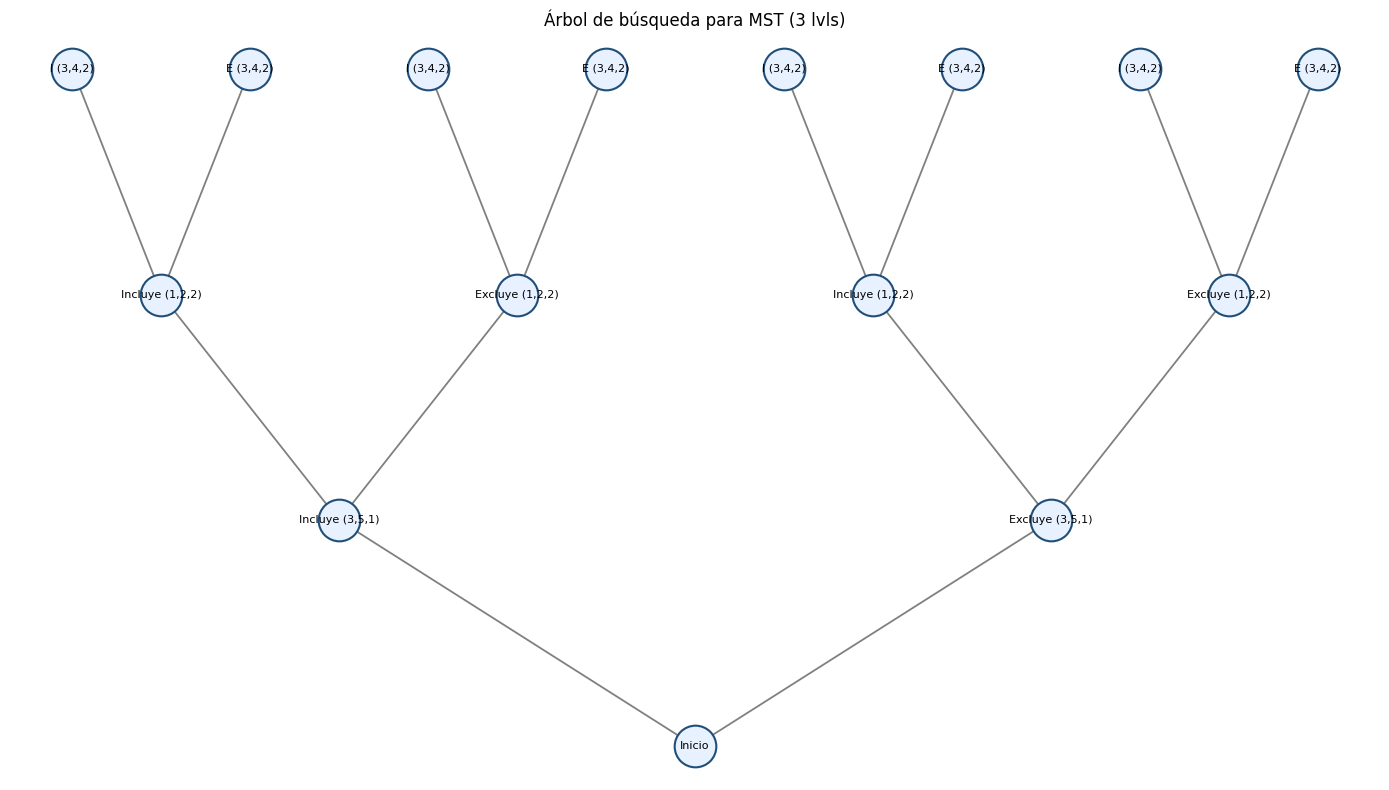

In [5]:
#figura del arbol de busqueda
import matplotlib.pyplot as plt


def draw_decision_tree_three_levels(level_edges):
    coords = {
        "root": (0.0, 1.0),
        "L1_I": (-4.0, 3.0),
        "L1_E": (4.0, 3.0),
        "L2_II": (-6.0, 5.0),
        "L2_IE": (-2.0, 5.0),
        "L2_EI": (2.0, 5.0),
        "L2_EE": (6.0, 5.0),
        "L3_III": (-7.0, 7.0),
        "L3_IIE": (-5.0, 7.0),
        "L3_IEI": (-3.0, 7.0),
        "L3_IEE": (-1.0, 7.0),
        "L3_EII": (1.0, 7.0),
        "L3_EIE": (3.0, 7.0),
        "L3_EEI": (5.0, 7.0),
        "L3_EEE": (7.0, 7.0),
    }

    u1, v1, w1 = level_edges[0]
    u2, v2, w2 = level_edges[1]
    u3, v3, w3 = level_edges[2]

    labels = {
        "root": "Inicio",
        "L1_I": f"Incluye ({u1},{v1},{w1})",
        "L1_E": f"Excluye ({u1},{v1},{w1})",
        "L2_II": f"Incluye ({u2},{v2},{w2})",
        "L2_IE": f"Excluye ({u2},{v2},{w2})",
        "L2_EI": f"Incluye ({u2},{v2},{w2})",
        "L2_EE": f"Excluye ({u2},{v2},{w2})",
        "L3_III": f"I ({u3},{v3},{w3})",
        "L3_IIE": f"E ({u3},{v3},{w3})",
        "L3_IEI": f"I ({u3},{v3},{w3})",
        "L3_IEE": f"E ({u3},{v3},{w3})",
        "L3_EII": f"I ({u3},{v3},{w3})",
        "L3_EIE": f"E ({u3},{v3},{w3})",
        "L3_EEI": f"I ({u3},{v3},{w3})",
        "L3_EEE": f"E ({u3},{v3},{w3})",
    }

    edges_plot = [
        ("root", "L1_I"), ("root", "L1_E"),
        ("L1_I", "L2_II"), ("L1_I", "L2_IE"),
        ("L1_E", "L2_EI"), ("L1_E", "L2_EE"),
        ("L2_II", "L3_III"), ("L2_II", "L3_IIE"),
        ("L2_IE", "L3_IEI"), ("L2_IE", "L3_IEE"),
        ("L2_EI", "L3_EII"), ("L2_EI", "L3_EIE"),
        ("L2_EE", "L3_EEI"), ("L2_EE", "L3_EEE"),
    ]

    plt.figure(figsize=(14, 8))

    for parent, child in edges_plot:
        x1, y1 = coords[parent]
        x2, y2 = coords[child]
        plt.plot([x1, x2], [y1, y2], color="gray", linewidth=1.3, zorder=1)

    for node, (x, y) in coords.items():
        plt.scatter(x, y, s=900, color="#E7F1FF", edgecolors="#1F4E79", linewidths=1.5, zorder=2)
        plt.text(x, y, labels[node], ha="center", va="center", fontsize=8, zorder=3)

    plt.title("Árbol de búsqueda para MST (3 lvls)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_decision_tree_three_levels(first_three)

## 3) Conclusiones 

- El problema del MST se modela como busqueda combinatoria sobre subconjuntos de aristas
- El espacio Omega crece exponencialmente: 2^m
- La funcion objetivo minimiza la suma de pesos
- Kruskal encuentra una solucion optima de forma eficiente para grafos conexos
- La prueba contra fuerza bruta en este ejemplo confirma que el codigo funciona